<a href="https://www.kaggle.com/code/lekhatopil/predicting-optimal-fertilizers-xgboost-lightgbm?scriptVersionId=292249759" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Introduction**
This notebook presents a multi-class classification solution to predict the most suitable fertilizer for a given agricultural scenario. The objective is to rank the **top 3 fertilizer** recommendations for each data point based on a variety of environmental and soil-related features.

The evaluation metric for this task is **Mean Average Precision at 3 (MAP@3)**, which emphasizes not just correct classification but the ranking quality of the predictions. 

The approach begins with understanding the relationship between features and the target variable (fertilizer_name) and analyzing the overall data distribution to guide informed preprocessing decisions. Advanced feature engineering techniques are applied to capture complex feature interactions, including soil-crop dynamics, climate stress indicators, and row-level nutrient balance patterns. 

To ensure robust model evaluation and avoid data leakage, a **5-Fold Stratified K-Fold cross-validation** strategy is used, maintaining balanced class distributions across all folds. The model training is carried out using both **LightGBM** and **XGBoost** algorithms. After evaluating both models, **LightGBM** was selected for the final test predictions due to its slightly better performance and consistency in validation scores.  

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import squarify

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier 

# Import packages for warnings
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')   

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
train_df = pd.read_csv("/kaggle/input/playground-series-s5e6/train.csv")      
test_df = pd.read_csv("/kaggle/input/playground-series-s5e6/test.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (750000, 10)
Test: (250000, 9)


In [3]:
train_df.head()   

,id,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,1,27,69,65,Sandy,Millets,30,6,18,28-28
2,2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,4,35,58,43,Red,Paddy,37,2,16,DAP


In [4]:
# Change column names to lower_case & replace space with underscore
train_df.columns = train_df.columns.str.replace(' ', '_').str.lower()
test_df.columns = test_df.columns.str.replace(' ', '_').str.lower()

In [5]:
print("Missing Values in Train:", train_df.isna().sum().sum())
print("Missing Values in Test:", test_df.isna().sum().sum())

print("Duplicates in Train:", train_df.drop(columns=['id']).duplicated().sum())
print("Duplicates in Test:", test_df.drop(columns=['id']).duplicated().sum())

Missing Values in Train: 0
Missing Values in Test: 0
Duplicates in Train: 0
Duplicates in Test: 0


* The training dataset consists of **750,000 rows** and **8 features** (excluding the **'id'** and **'fertilizer_name'**). The test dataset contains **250,000 rows** with the same **8 features**. 
* The target variable, **`fertilizer_name`**, is a **multi-class** categorical feature with **7 distinct fertilizer types**.
* Both the training and test datasets are clean, with **no missing values or duplicate records**

# **Data Distribution**

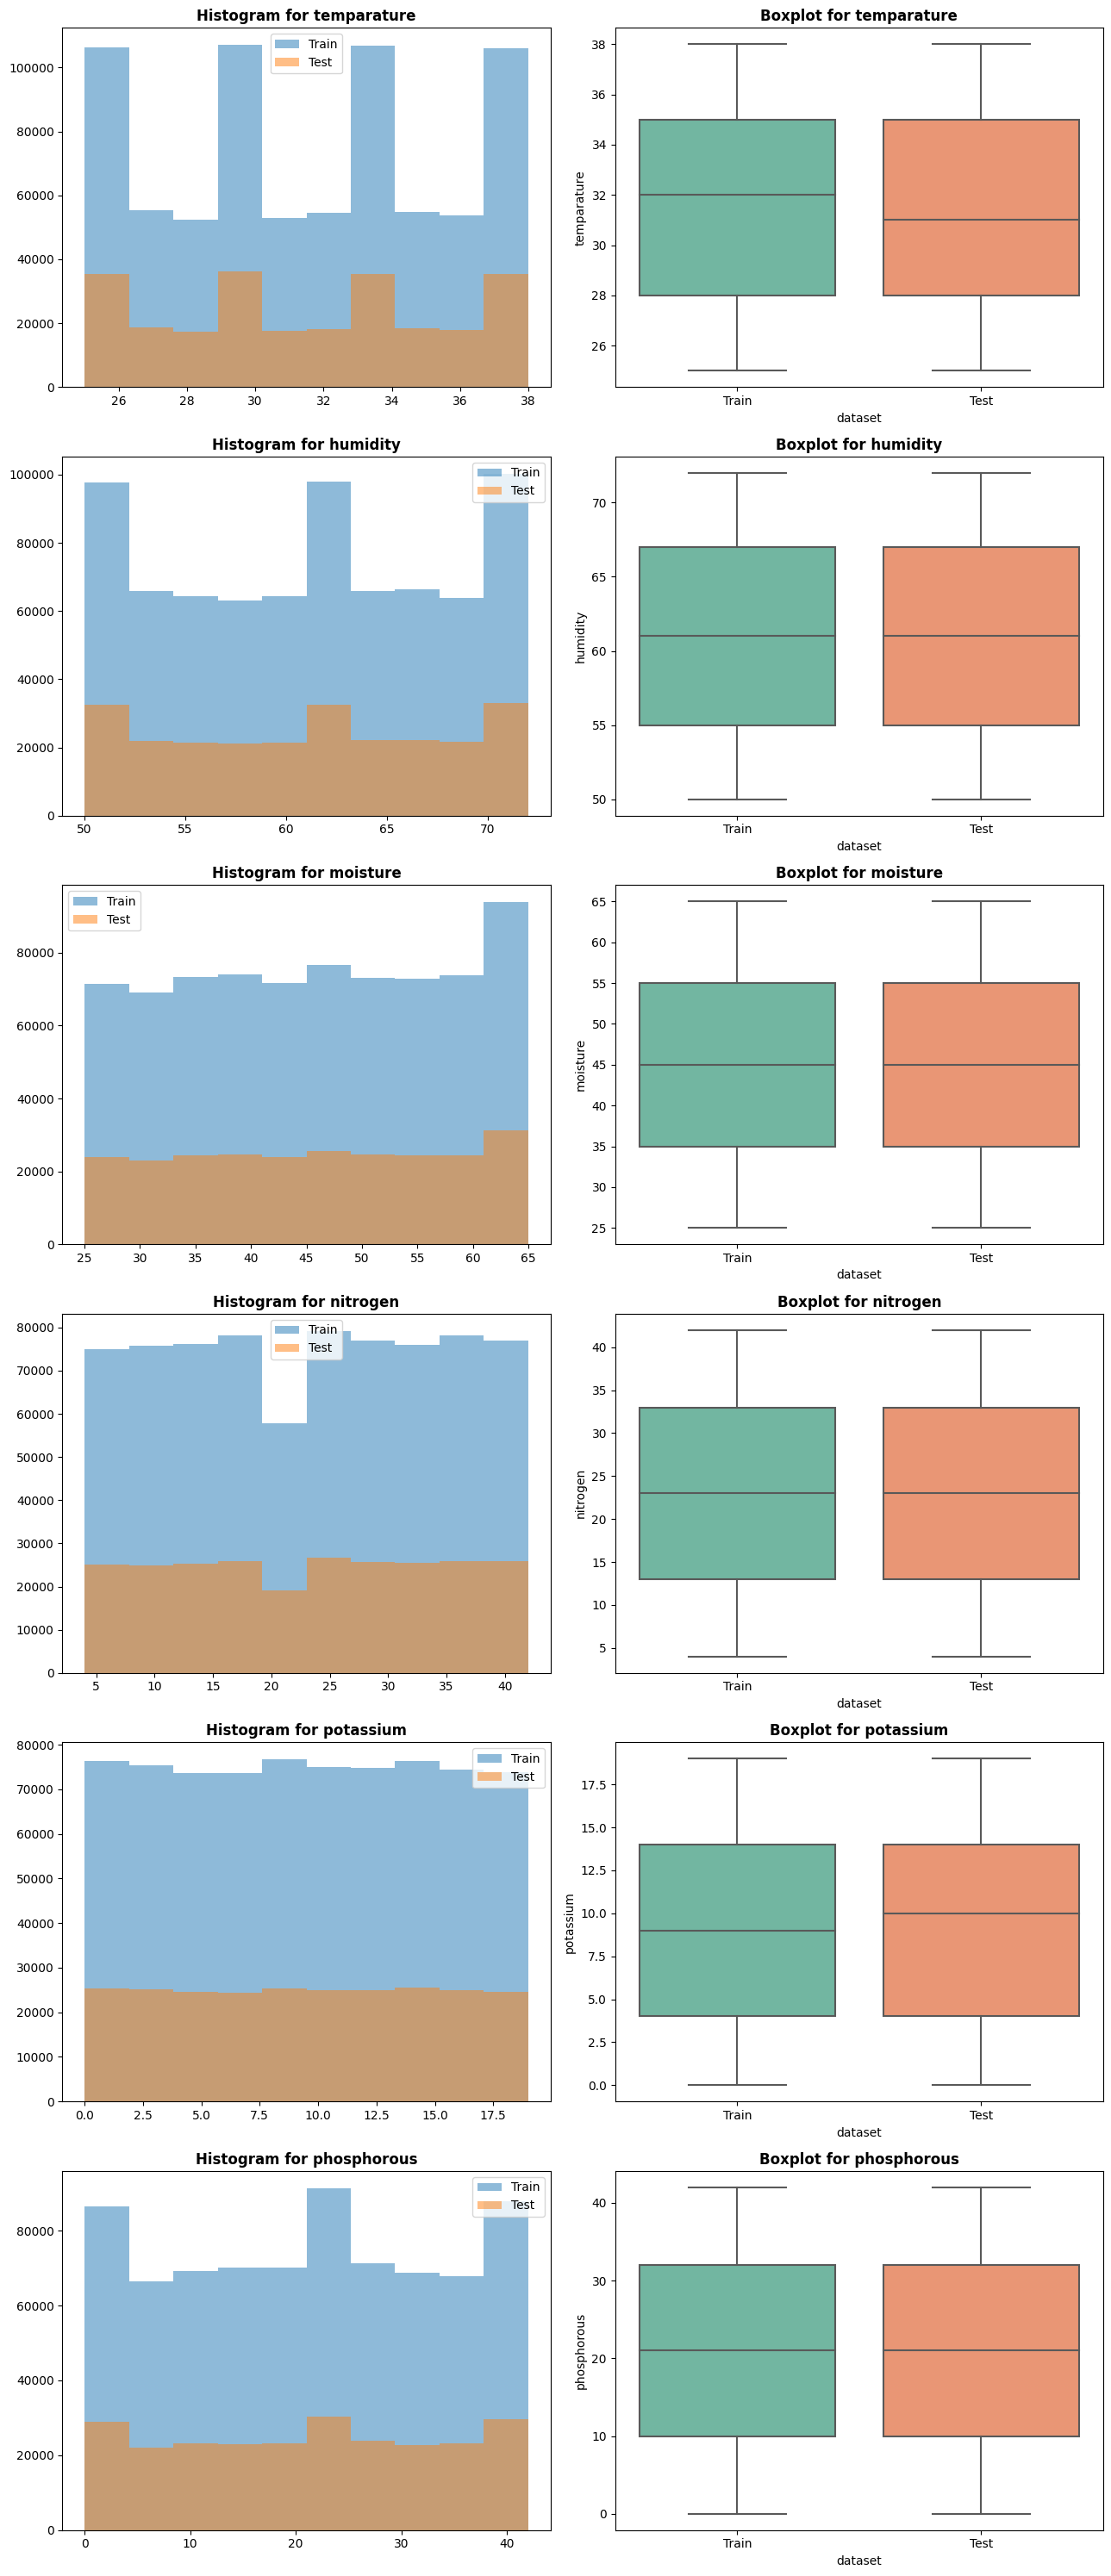

In [6]:
num_col = train_df.drop(columns=['id']).select_dtypes(include=['int', 'float64']).columns.tolist() 

# Setup subplots
fig, axes = plt.subplots(len(num_col), 2, figsize=(13, 5 * len(num_col)))

# Plot histogram for train_df and test_df
for i, var in enumerate(num_col):
    axes[i, 0].hist(train_df[var], alpha=0.5, label='Train')
    axes[i, 0].hist(test_df[var], alpha=0.5, label='Test')
    axes[i, 0].set_title(f'Histogram for {var}', weight='bold')
    axes[i, 0].legend()

    # Prepare data for boxplot
    combined = pd.concat([train_df[var].to_frame().assign(dataset='Train'),
                          test_df[var].to_frame().assign(dataset='Test')])    

    # Plot boxplot
    sns.boxplot(data=combined, x='dataset', y=var, ax=axes[i, 1], palette='Set2')
    axes[i, 1].set_title(f'Boxplot for {var}', weight='bold')

plt.tight_layout()
plt.show()   

* There are **six numerical features** in this dataset. Histograms and boxplots reveal that the training and test datasets share a **similar distribution shape** across these features, with **no outliers** detected. This consistency indicates that both datasets are well-aligned. 

# **Categorical Data Distribution**

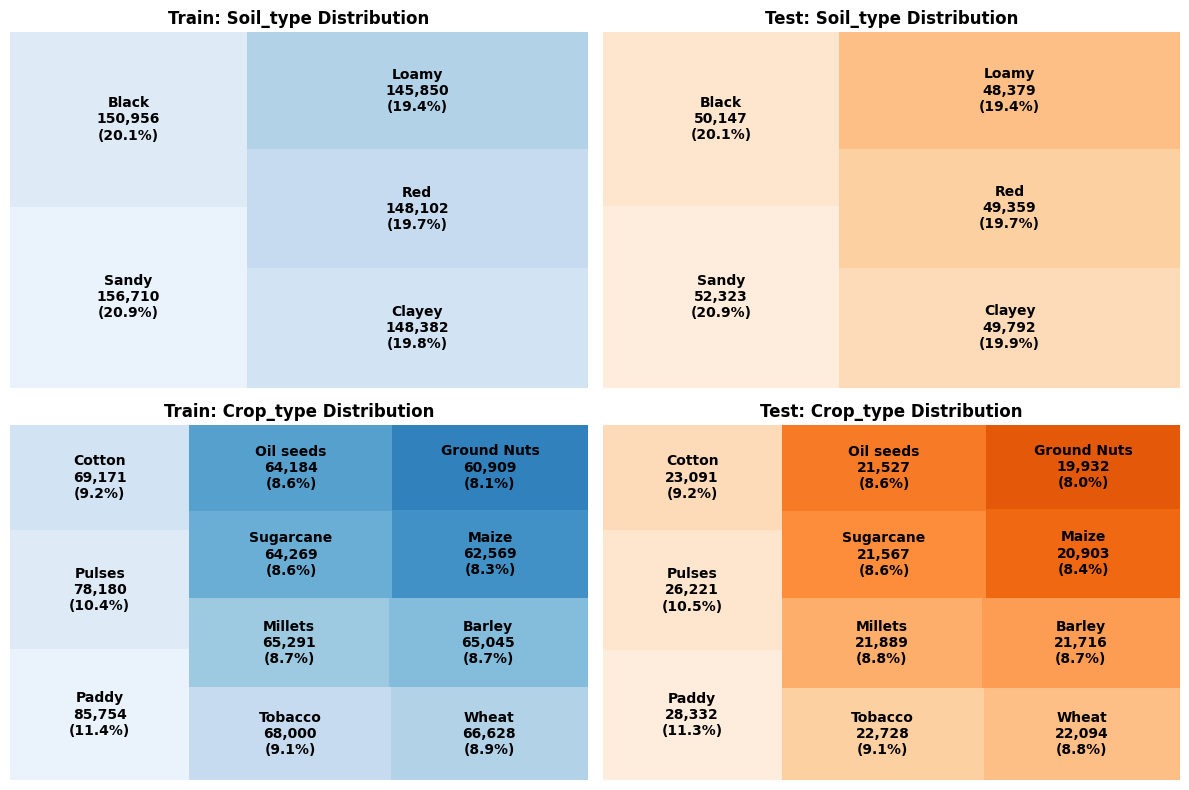

In [7]:
cat_col = train_df.drop(columns=['fertilizer_name']).select_dtypes(include=['object']).columns.tolist()

n_rows = len(cat_col)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows), squeeze=False)

# Set Color palette
train_colors = sns.color_palette("Blues", n_colors=15)  
test_colors = sns.color_palette("Oranges", n_colors=15)

# Iterate over categorical variables
for i, var in enumerate(cat_col):
    # Calculate value counts for train and test
    train_counts = train_df[var].value_counts()
    test_counts = test_df[var].value_counts()
    
    # Get labels and sizes for treemaps
    train_labels = [f"{cat}\n{count:,}\n({count/len(train_df)*100:.1f}%)"
                    for cat, count in train_counts.items()]
    test_labels = [f"{cat}\n{count:,}\n({count/len(test_df)*100:.1f}%)"
                   for cat, count in test_counts.items()]
    train_sizes = train_counts.values
    test_sizes = test_counts.values
    
    # Plot treemap for train data
    axes[i, 0].set_title(f"Train: {var.capitalize()} Distribution", weight='bold')
    squarify.plot(sizes=train_sizes, label=train_labels, color=train_colors[:len(train_sizes)], ax=axes[i, 0],
        text_kwargs={'fontsize': 10, 'weight': 'bold'})
    axes[i, 0].axis('off') 
    
    # Plot treemap for test data
    axes[i, 1].set_title(f"Test: {var.capitalize()} Distribution", weight='bold')
    squarify.plot(sizes=test_sizes, label=test_labels, color=test_colors[:len(test_sizes)], ax=axes[i, 1],
        text_kwargs={'fontsize': 10, 'weight': 'bold'})
    axes[i, 1].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()             

* The dataset contains **two categorical features:** **`soil_type`** with **5** unique categories and **`crop_type`** with **11** unique categories.
* The distribution of these features is **fairly balanced** in both the training and test sets.
* For **`soil_type`**, each category comprises roughly **19–21%** of the data, while **`crop_type`** categories range from approximately **8% to 11%**.
* The distribution patterns are **very similar** between the training and test datasets, indicating a consistent sampling strategy and **no significant class imbalance** in the categorical features.

# **Target Variable Data Distribution: Fertilizer Name**

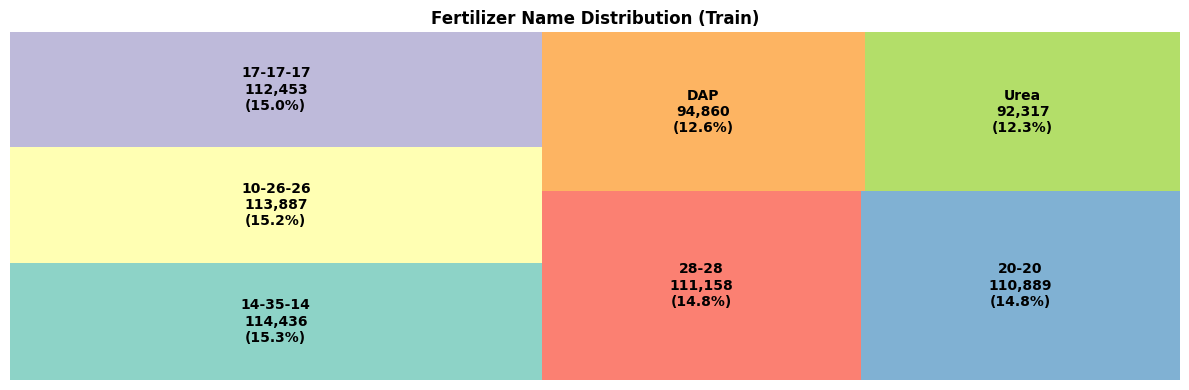

In [8]:
# Set figure size
plt.figure(figsize=(12, 4))

# Color palette 
colors = sns.color_palette("Set3", n_colors=10)  

# Calculate value counts for fertilizer_name
train_counts = train_df['fertilizer_name'].value_counts()

# Get labels and sizes for treemap
labels = [f"{cat}\n{count:,}\n({count/len(train_df)*100:.1f}%)"
          for cat, count in train_counts.items()]
sizes = train_counts.values

# Plot treemap
squarify.plot(sizes=sizes, label=labels,color=colors,
    text_kwargs={'fontsize': 10, 'weight': 'bold'})
plt.title("Fertilizer Name Distribution (Train)", weight='bold')
plt.axis('off')

# Adjust layout
plt.tight_layout()
plt.show() 

* The target variable **`fertilizer_name`** exhibits a **fairly uniform distribution** across its **7** unique categories, with proportions ranging from approximately **12% to 15%**.
* This indicates there is **no significant class imbalance**, and therefore, **no sampling or rebalancing** techniques are required during model training.

# **Distribution of Numerical Features by Fertilizer Class (KDE + Boxplots)**

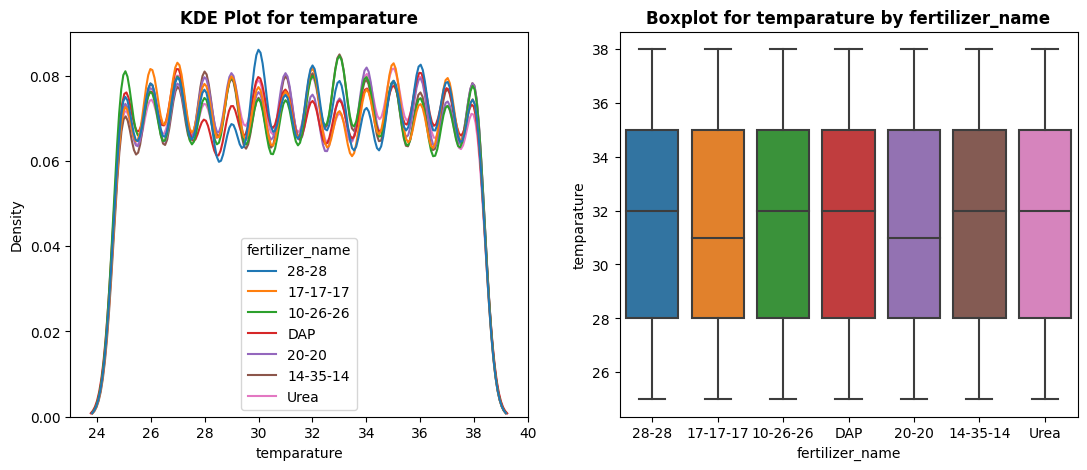

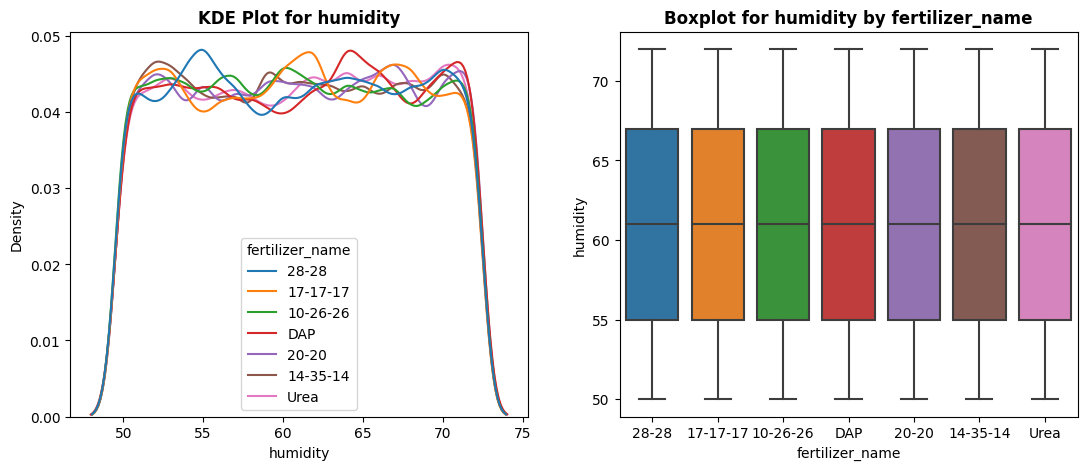

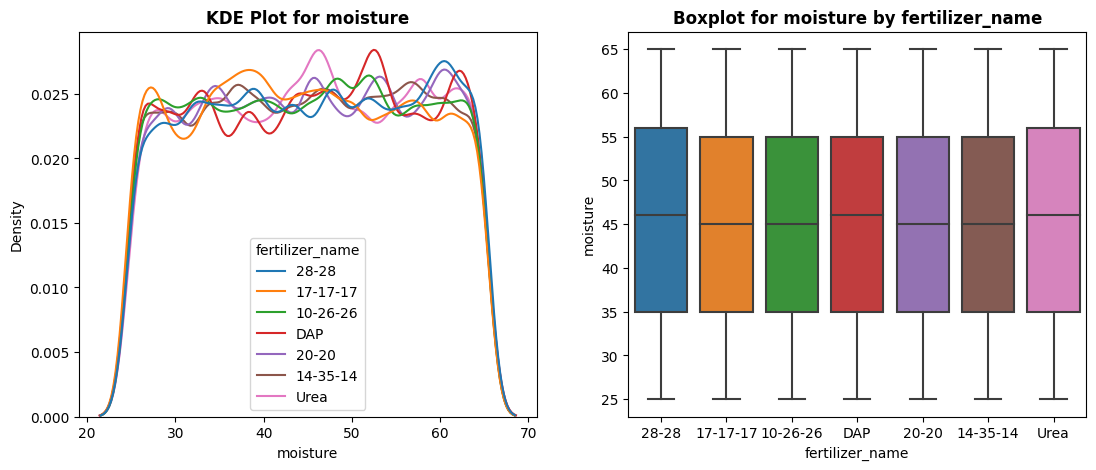

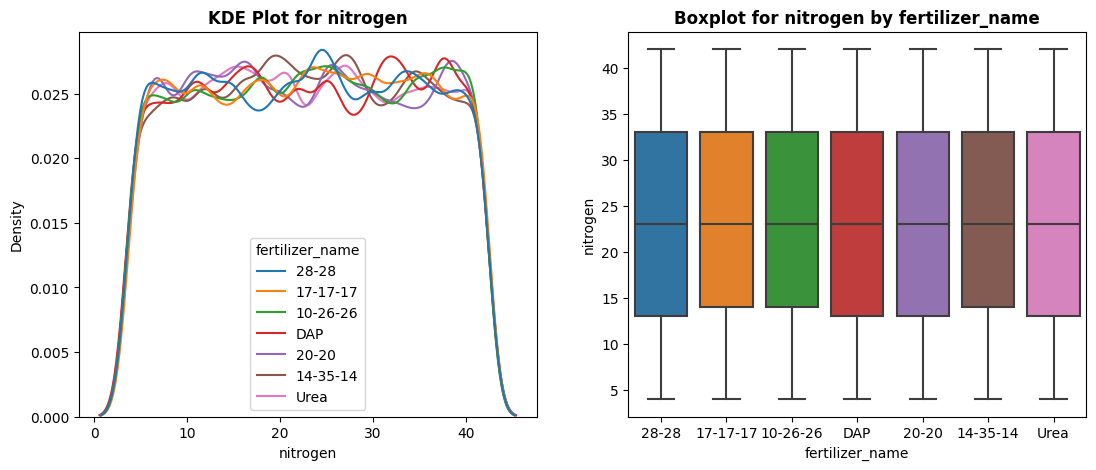

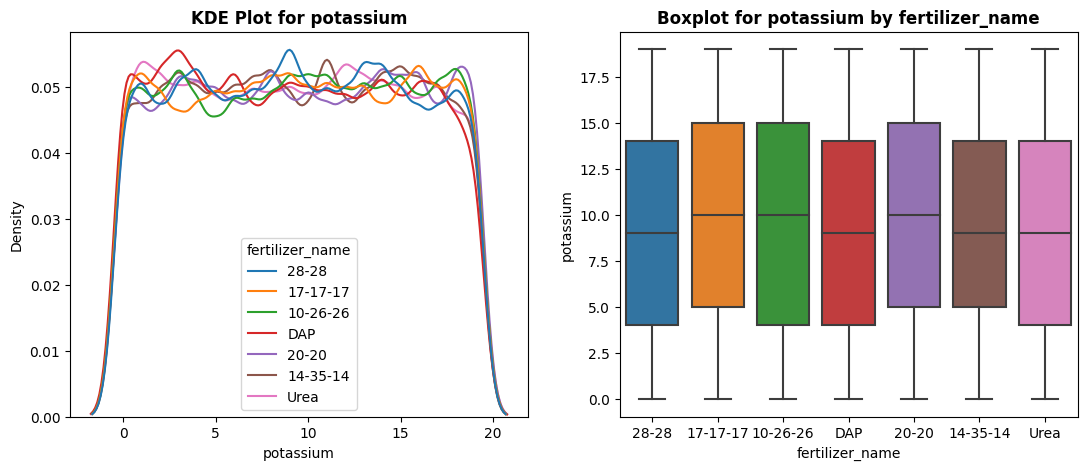

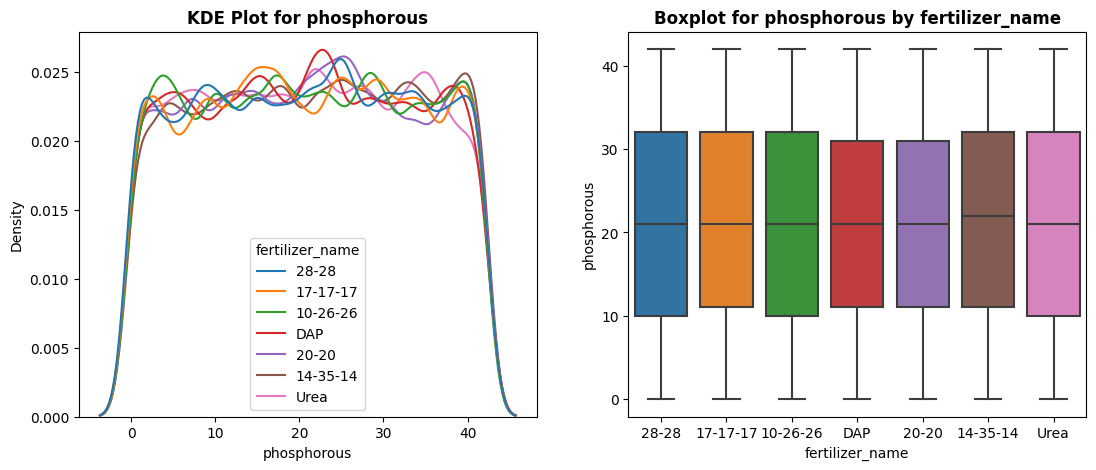

In [9]:
def kde_boxplot(col_name):          
    # Setup subplots
    fig, axes = plt.subplots(1, 2, figsize=(13, 5 * 1))
    # Create KDE plot
    sns.kdeplot(data=train_df, x=col_name, hue='fertilizer_name', common_norm=False, ax=axes[0])
    axes[0].set_title(f'KDE Plot for {col_name}', weight='bold')
    # Create boxplot 
    sns.boxplot(data=train_df, x='fertilizer_name', y=col_name)  
    axes[1].set_title(f'Boxplot for {col_name} by fertilizer_name', weight='bold')
    plt.show()   

kde_boxplot('temparature')
kde_boxplot('humidity')
kde_boxplot('moisture')
kde_boxplot('nitrogen')
kde_boxplot('potassium')
kde_boxplot('phosphorous')

* The numerical features (temperature, humidity, moisture, nitrogen, phosphorous, potassium) exhibit very similar distributions across the different fertilizer classes.
* **KDE plots** and **boxplots** show **substantial overlap** between categories, and the summary statistics (mean, median, IQR) across fertilizers differ only marginally.
* This indicates that no single numerical feature distinctly separates one fertilizer class from another, suggesting the model must rely on subtle multivariate patterns or engineered features for accurate predictions.

# **Correlation**

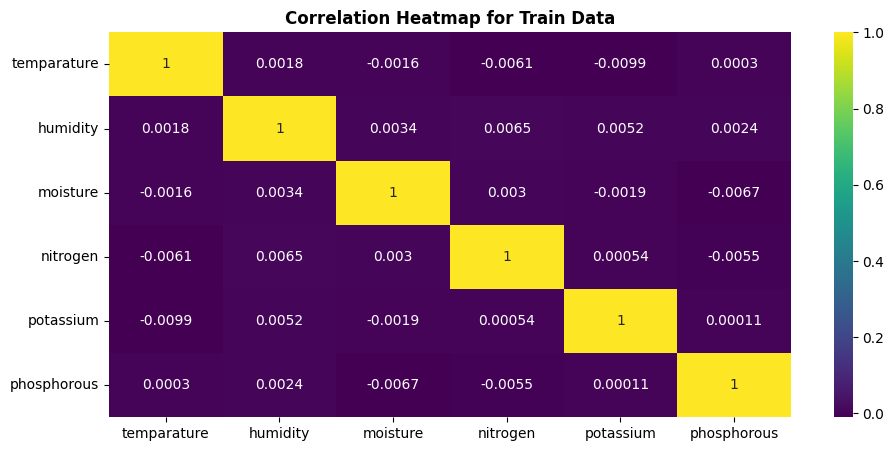

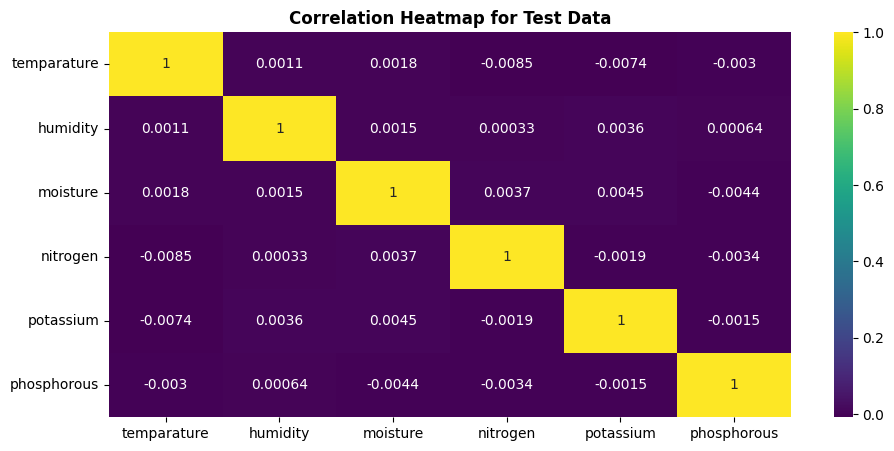

In [10]:
# Heatmap for train_df
plt.figure(figsize=(11, 5))
sns.heatmap(train_df.drop(columns=['id']).corr(method='pearson', numeric_only=True), annot=True, cmap='viridis')
plt.title('Correlation Heatmap for Train Data', fontsize=12, weight='bold')
plt.show();

# Heatmap for test_df
plt.figure(figsize=(11, 5))
sns.heatmap(test_df.drop(columns=['id']).corr(method='pearson', numeric_only=True), annot=True, cmap='viridis')
plt.title('Correlation Heatmap for Test Data', fontsize=12, weight='bold')
plt.show();          

* The correlation heatmap shows that numerical features have **no pairwise correlation**, indicating minimal or no linear relationships. While multicollinearity isn't a concern for tree-based models, this confirms feature diversity and helps validate the dataset structure.

# **Feature Engineering**
## **Interaction, Ratio-based, Non-linear Features**

Although the dataset is synthetically generated using deep learning techniques, I attempted to engineer **domain-specific features** inspired by real-world agricultural patterns. These features include nutrient ratios, climate stress indicators, and soil-crop interactions, which are typically influential in fertilizer recommendation systems.     

Composite features like **`npk_sum`**, **npk ratios**, **`climate_sum`**, **climate differences**, **climate ratio**, and **`soil_crop_combo`** help capture agronomic and environmental conditions more holistically. 

Additional derived features such as nutrient balance (**`npk_balance`**), drought stress (**`hot_dry_conditions`**), and ideal growing conditions (**`ideal_growing_conditions`**) were engineered to reflect physiological impacts on fertilizer response. These features were designed to model the complex, non-linear interactions that influence fertilizer recommendations.

However, given the artificial nature of the data, it's uncertain whether these engineered features align with real agronomic behavior. The goal was to introduce meaningful complexity that could help the model generalize better, even in a simulated environment.

In [11]:
def create_features(df):
    # Categorical combos
    df['soil_crop_combo'] = df['soil_type'] +  "_" + df['crop_type']
    df['npk_sum'] = df['nitrogen'] + df['potassium'] + df['phosphorous']
    
    # Climate difference
    df['temp_moisture_diff'] = df['temparature'] - df['moisture']
    df['humidity_temp_diff'] = df['humidity'] - df['temparature']
    df['humidity_moisture_diff'] = df['humidity'] - df['moisture']
    
    # Climate ratio
    df['humidity_moisture_ratio'] = df['humidity'] / df['moisture']
    df['temp_humidity_ratio'] = df['temparature'] / df['humidity']
    df['temp_moisture_ratio'] = df['temparature'] / df['moisture']

    # Climate normalized ratios 
    df['climate_sum'] = df['temparature'] + df['humidity'] + df['moisture']
    df['temp_pct'] = df['temparature'] / df['climate_sum']
    df['humidity_pct'] = df['humidity'] / df['climate_sum']
    df['moisture_pct'] = df['moisture'] / df['climate_sum'] 

    # Interaction features
    df['temp_humidity_moisture'] = df['temparature'] * df['humidity'] * df['moisture']
    df['nitrogen_phosphorous_potassium'] = df['nitrogen'] * df['phosphorous'] * df['potassium']

    # NPK ratios 
    df['n_p_ratio'] = df['nitrogen'] / np.where(df['phosphorous'] == 0, 1, df['phosphorous'])
    df['n_k_ratio'] = df['nitrogen'] / np.where(df['potassium'] == 0, 1, df['potassium'])
    df['p_k_ratio'] = df['phosphorous'] / np.where(df['potassium'] == 0, 1, df['potassium']) 

    # Nutrient balance index
    df['npk_balance'] = df['npk_sum'] / 3 - np.std([df['nitrogen'], df['phosphorous'], df['potassium']], axis=0)
    # Heat-drought stress signal
    df['hot_dry_conditions'] = df['temp_pct'] * (1 - df['humidity_pct'])  
    # Balanced climate score 
    df['ideal_growing_conditions'] = 1 / (1 + abs(df['temp_pct'] - 0.33) + abs(df['humidity_pct'] - 0.33) + abs(df['moisture_pct'] - 0.33))      

    return df


def create_interaction_features(df):
    # Create climate interaction features
    climate_features = ['temparature', 'humidity', 'moisture']
    for i, col1 in enumerate(climate_features):
        for col2 in climate_features[i+1:]:
            df[f"{col1}_x_{col2}"] = df[col1] * df[col2] 

    # Create NPK interaction featuers 
    npk_features = ['nitrogen',	'potassium', 'phosphorous']
    for i, col1 in enumerate(npk_features):
        for col2 in npk_features[i+1:]:
            df[f"{col1}_x_{col2}"] = df[col1] * df[col2]
            
    # Create selective climate & npk interaction features
    df['nitrogen_x_temp'] = df['nitrogen'] * df['temparature']
    df['phosphorous_x_moisture'] = df['phosphorous'] * df['moisture']
    df['npk_sum_x_temp'] = df['npk_sum'] * df['temparature']
    df['potassium_x_humidity'] = df['potassium'] * df['humidity']

    return df

# Apply create_features
train_df = create_features(train_df)
test_df = create_features(test_df)

# Apply create_interaction_features
train_df = create_interaction_features(train_df)
test_df = create_interaction_features(test_df)
train_df.head(1)           

,id,temparature,humidity,moisture,soil_type,crop_type,nitrogen,potassium,phosphorous,fertilizer_name,soil_crop_combo,npk_sum,temp_moisture_diff,humidity_temp_diff,humidity_moisture_diff,humidity_moisture_ratio,temp_humidity_ratio,temp_moisture_ratio,climate_sum,temp_pct,humidity_pct,moisture_pct,temp_humidity_moisture,nitrogen_phosphorous_potassium,n_p_ratio,n_k_ratio,p_k_ratio,npk_balance,hot_dry_conditions,ideal_growing_conditions,temparature_x_humidity,temparature_x_moisture,humidity_x_moisture,nitrogen_x_potassium,nitrogen_x_phosphorous,potassium_x_phosphorous,nitrogen_x_temp,phosphorous_x_moisture,npk_sum_x_temp,potassium_x_humidity
0,0,37,70,36,Clayey,Sugarcane,36,4,5,28-28,Clayey_Sugarcane,45,1,33,34,1.944444,0.528571,1.027778,143,0.258741,0.48951,0.251748,93240,720,7.2,9.0,1.25,0.145147,0.132085,0.76393,2590,1332,2520,144,180,20,1332,180,1665,280


## **Probability Encoding Based on Categorical Groupings**

* This function generates group-wise fertilizer probability features by one-hot encoding the target variable (**`fertilizer_name`**) and **calculating the mean distribution** of fertilizer labels within each group (**`soil_crop_combo`**).
* To prevent data leakage, the **mean probabilities** are computed **only from the training fold** within each iteration of Stratified K-Fold cross-validation.
* These probability-based features are then merged into the training, validation, and test sets, helping the model capture historical label tendencies tied to specific categorical groups.

These features capture the historical distribution of fertilizer labels within the specific groups of **`soil_type`** and **`crop_type`**, which might help the model to learn label likelihoods. For example, if a certain **`crop_type`** + **`soil_type`** frequently uses a specific fertilizer, this encoding provides a probabilistic prior that might guide the model toward more informed predictions, especially useful in noisy or synthetic datasets.

In [12]:
def create_fertilizer_prob_features(train_df, valid_df, test_df, group_col, target_col):
    fertilizer_ohe = pd.get_dummies(train_df[target_col], prefix='prob_', dtype=float)
    temp_df = pd.concat([train_df[group_col].reset_index(drop=True), fertilizer_ohe], axis=1)
    group_prob = temp_df.groupby(group_col).mean().reset_index()

    train_df = train_df.merge(group_prob, on=group_col, how='left')
    valid_df = valid_df.merge(group_prob, on=group_col, how='left')
    test_df = test_df.merge(group_prob, on=group_col, how='left')
    return train_df, valid_df, test_df           

In [13]:
# Changing the datatype for categorical variables from object to category in train_df 
for col in train_df.select_dtypes('object').columns:
    train_df[col] = train_df[col].astype('category')

# Changing the datatype for categorical variables from object to category in test_df 
for col in test_df.select_dtypes('object').columns:
    test_df[col] = test_df[col].astype('category')    

# **Model Building**

For submission, I selected **two approaches:** a blended ensemble of three models (**LightGBM, XGBoost, and CatBoost**) using Optuna-based weights, and a **single LightGBM model**. Although the ensemble showed slight improvement during cross-validation, the LightGBM model performed marginally better on the private leaderboard.

As a result, the test predictions in this notebook are generated using the **single LightGBM model**. This notebook demonstrates the training process for both LightGBM and XGBoost models for comparison and interpretability. 


In [14]:
# Features & Target  
X = train_df.drop(columns=['id'])
X_test = test_df.drop(columns=['id'])

y = train_df['fertilizer_name']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# MAP@3 function
def mapk(actual, predicted, k=3):
    def apk(a, p, k):
        if a in p[:k]:
            return 1.0 / (p[:k].index(a) + 1)
        return 0.0
    
    return np.mean([apk(a, p, k) for a, p in zip(actual, predicted)])


# LightGBM hyper-parameter
lgbm_params = {
    'n_estimators': 12000,
    'learning_rate': 0.01,
    'subsample': 0.75, 
    'colsample_bytree': 0.75,
    'reg_lambda': 0.3, 
    'reg_alpha': 0.3, 
    'num_leaves': 64, 
    'max_depth': 10, 
    'min_child_samples': 30, 
    'boosting_type': 'gbdt',
    'objective': 'multiclass',
    'num_class': 7,
    'device': 'gpu',
    'random_state': 42,
    'verbosity': -1,
}

# XGBoost hyper-parameter
xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'max_depth': 10,
    'subsample': 0.75,
    'colsample_bytree': 0.75,
    'reg_lambda': 0.3,
    'reg_alpha': 0.3,
    'objective': 'multi:softprob',
    'num_class': 7, 
    'tree_method': 'gpu_hist',  
    'enable_categorical':True,
    'random_state': 42
}

In [15]:
def train_model(X, y, X_test, model_name, params):
    print(f"\n##### Training {model_name} Model #####")

    oof_preds = np.zeros((X.shape[0], len(np.unique(y))))
    test_preds = np.zeros((X_test.shape[0], len(np.unique(y))))
    map3_scores = []
    feature_importances = pd.DataFrame()
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        print(f"\n### Fold {fold+1} ###")

        X_train, y_train = X.iloc[train_idx], y_encoded[train_idx]
        X_valid, y_valid = X.iloc[valid_idx], y_encoded[valid_idx]
        X_test_fold = X_test.copy()
        
        # Add fertilizer probabilities features
        X_train, X_valid, X_test_fold = create_fertilizer_prob_features(
            train_df=X_train,
            valid_df=X_valid,
            test_df=X_test_fold,
            group_col='soil_type',
            target_col='fertilizer_name'
        )

        # Drop Target variable 
        X_train.drop(columns=['fertilizer_name'], inplace=True)
        X_valid.drop(columns=['fertilizer_name'], inplace=True)
        
        # Train model
        if model_name == "LightGBM":
            model = lgb.LGBMClassifier(**params)
            model.fit(X_train, y_train, 
                      eval_set=[(X_valid, y_valid)],
                      callbacks=[early_stopping(stopping_rounds=100, verbose=False)])
            
            # Feature importance
            fold_importance = pd.DataFrame({
                'feature': X_train.columns,
                'importance': model.feature_importances_,
                'fold': fold + 1
            })
            feature_importances = pd.concat([feature_importances, fold_importance], axis=0)

        elif model_name == "XGBoost":
            model = XGBClassifier(**params)
            model.fit(X_train, y_train,
                      eval_set=[(X_valid, y_valid)],
                      early_stopping_rounds=50,
                      verbose=100)

            # Feature importance
            importance_dict = model.get_booster().get_score(importance_type='gain')
            fold_importance = pd.DataFrame({
            "feature": X_train.columns,
            "importance": [importance_dict.get(feat, 0) for feat in X_train.columns],
            "fold": fold + 1})
            feature_importances = pd.concat([feature_importances, fold_importance], axis=0)

        else:
            raise ValueError("Invalid model_name. Choose 'LightGBM' or 'XGBoost'.")

        # Validation & test predictions
        valid_preds = model.predict_proba(X_valid)
        test_preds += model.predict_proba(X_test_fold) / skf.n_splits
        
        # OOF predictions
        oof_preds[valid_idx] = valid_preds

        # MAP@3 Score
        top3_preds = np.argsort(valid_preds, axis=1)[:, -3:][:, ::-1]
        top3_labels = [[le.inverse_transform([i])[0] for i in row] for row in top3_preds]    
        true_labels = le.inverse_transform(y_valid)
        map3 = mapk(true_labels, top3_labels, k=3)
        print(f"Fold {fold + 1} MAP@3: {map3:.5f}")
        map3_scores.append(map3)   

    # Average MAP@3 score
    print(f"\nAverage MAP@3: {np.mean(map3_scores):.5f}")
    
    # Final OOF MAP@3 Score
    top3_preds_oof = np.argsort(oof_preds, axis=1)[:, -3:][:, ::-1]
    top3_labels_oof = [[le.inverse_transform([i])[0] for i in row] for row in top3_preds_oof]
    true_labels_oof = le.inverse_transform(y_encoded)
    oof_map3 = mapk(true_labels_oof, top3_labels_oof, k=3)
    print(f"OOF MAP@3 Score: {oof_map3:.5f}\n")

    return oof_preds, test_preds, feature_importances, map3_scores    

In [16]:
%%time                
# Run XGBoost
xgb_oof, xgb_test, xgb_feature_importances, xgb_scores = train_model(X, y, X_test, model_name='XGBoost', params=xgb_params)


##### Training XGBoost Model #####

### Fold 1 ###
[0]	validation_0-mlogloss:1.94579
[100]	validation_0-mlogloss:1.93784
[200]	validation_0-mlogloss:1.93394
[300]	validation_0-mlogloss:1.93159
[400]	validation_0-mlogloss:1.92990
[500]	validation_0-mlogloss:1.92863
[600]	validation_0-mlogloss:1.92765
[700]	validation_0-mlogloss:1.92688
[800]	validation_0-mlogloss:1.92642
[900]	validation_0-mlogloss:1.92601
[1000]	validation_0-mlogloss:1.92574
[1100]	validation_0-mlogloss:1.92557
[1200]	validation_0-mlogloss:1.92547
[1300]	validation_0-mlogloss:1.92544
[1353]	validation_0-mlogloss:1.92546
Fold 1 MAP@3: 0.32236

### Fold 2 ###
[0]	validation_0-mlogloss:1.94579
[100]	validation_0-mlogloss:1.93775
[200]	validation_0-mlogloss:1.93387
[300]	validation_0-mlogloss:1.93145
[400]	validation_0-mlogloss:1.92985
[500]	validation_0-mlogloss:1.92865
[600]	validation_0-mlogloss:1.92770
[700]	validation_0-mlogloss:1.92703
[800]	validation_0-mlogloss:1.92653
[900]	validation_0-mlogloss:1.92613
[1000]	va

In [17]:
%%time                
# Run LightGBM    
lgbm_oof, lgbm_test, lgbm_feature_importances, lgbm_scores = train_model(X, y, X_test, model_name='LightGBM', params=lgbm_params)


##### Training LightGBM Model #####

### Fold 1 ###


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Fold 1 MAP@3: 0.32466

### Fold 2 ###
Fold 2 MAP@3: 0.32154

### Fold 3 ###
Fold 3 MAP@3: 0.32243

### Fold 4 ###
Fold 4 MAP@3: 0.32188

### Fold 5 ###
Fold 5 MAP@3: 0.32196

Average MAP@3: 0.32250
OOF MAP@3 Score: 0.32250

CPU times: user 2h 29min 45s, sys: 59.4 s, total: 2h 30min 44s
Wall time: 1h 17min 18s


# **Feature Importance**
* The most important feature in both models was the combination (**`soil_crop_combo`**) of **`soil_type`** and **`crop_type`**, highlighting the strong relationship between agricultural context and fertilizer recommendation. 
* Engineered features based on **nutrient ratios (NPK)**, their **interactions, climate-based combinations, and selective cross-features** between climate and nutrients contributed meaningfully to the model, while most of the raw features were less predictive. 
* **NPK-derived** features like **`npk_balance`**, **`n_p_ratio`**, **`n_k_ratio`**, **`p_k_ratio`**, **`npk_sum_x_temp`**, **`hot_dry_conditions`** along with interaction terms such as **`nitrogen_x_temp`** and **`phosphorous_x_moisture`**, consistently appeared in the **top 10-15** features across both models.
* On the other hand, target encoding via fertilizer class probabilities based on **soil-crop groups** added limited value, possibly due to the synthetic nature of the dataset. 

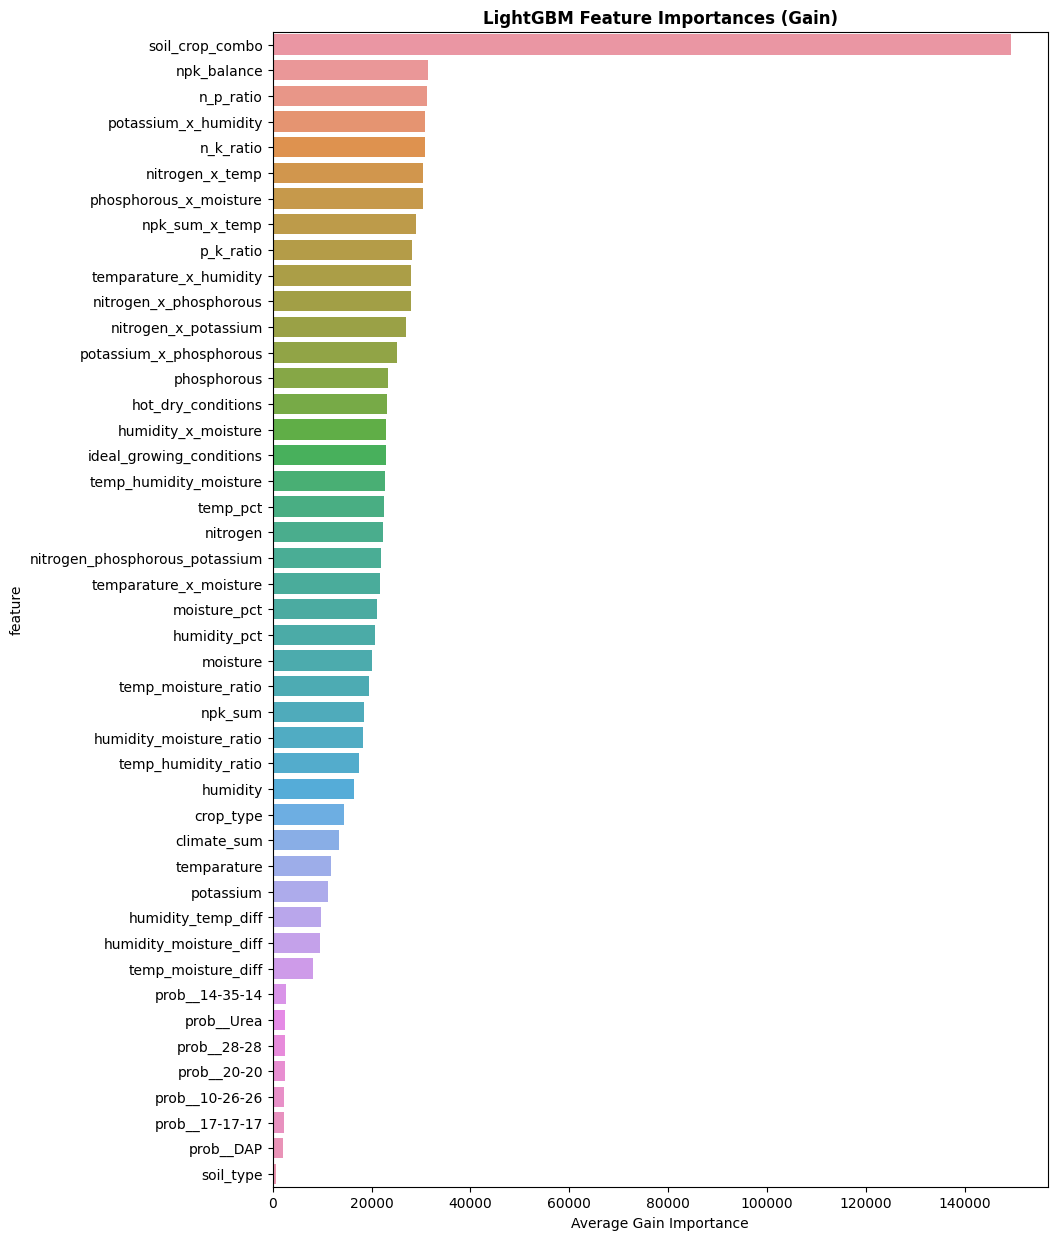

In [18]:
# Average importance from LightGBM
lgb_avg_importance = lgbm_feature_importances.groupby('feature')['importance'].mean().sort_values(ascending=False).reset_index()

# Plot LightGBM feature importance 
plt.figure(figsize=(10, 15))
sns.barplot(data=lgb_avg_importance, x='importance', y='feature')
plt.title("LightGBM Feature Importances (Gain)", weight="bold")
plt.xlabel("Average Gain Importance");       

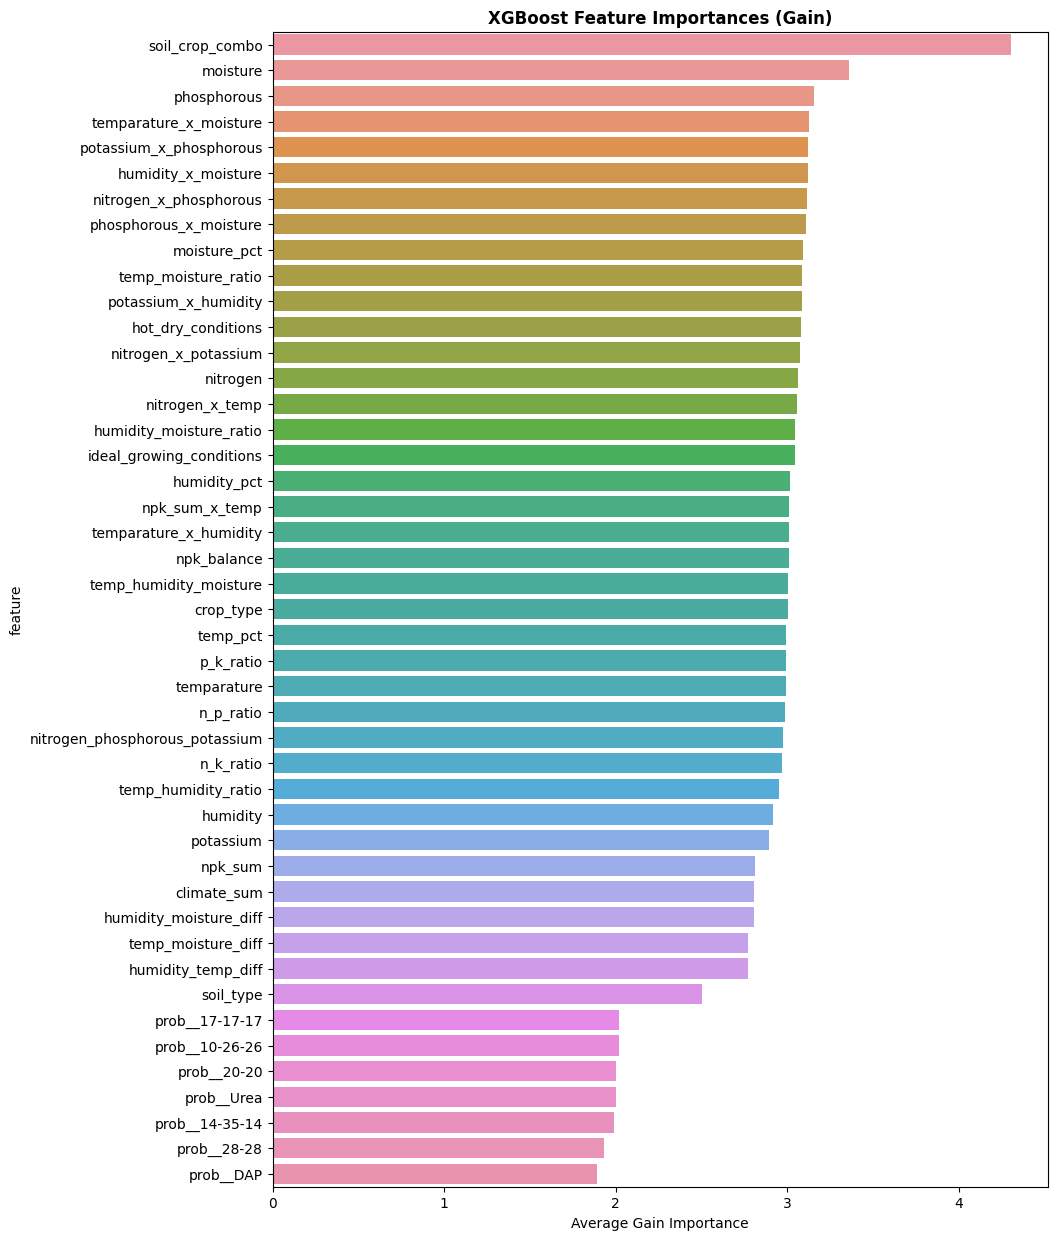

In [19]:
# Average importance from XGBoost
xgb_avg_importance = xgb_feature_importances.groupby('feature')['importance'].mean().sort_values(ascending=False).reset_index()

# Plot XGBoost feature importance 
plt.figure(figsize=(10, 15))
sns.barplot(data=xgb_avg_importance, x='importance', y='feature')
plt.title("XGBoost Feature Importances (Gain)", weight="bold")
plt.xlabel("Average Gain Importance");       

In [20]:
# Get top 3 predicted class indices from probabilities   
top3_preds_test = np.argsort(lgbm_test, axis=1)[:, -3:][:, ::-1]

# Convert class indices to fertilizer names using the label encoder
top3_labels_test = [
    " ".join([le.inverse_transform([i])[0] for i in row]) for row in top3_preds_test
]

# Prepare submission DataFrame
submission = pd.DataFrame({
    'id': test_df['id'],
    'Fertilizer Name': top3_labels_test
})

# Save the submission file
submission.to_csv("submission.csv", index=False)
print("Final submission file created")  

submission.head()    

Final submission file created


,id,Fertilizer Name
0,750000,28-28 17-17-17 DAP
1,750001,17-17-17 20-20 10-26-26
2,750002,20-20 14-35-14 28-28
3,750003,14-35-14 17-17-17 Urea
4,750004,20-20 10-26-26 14-35-14
